In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

pd.set_option("display.max_columns", None)

events = pd.read_csv(
    "viirs_night_2023_2024_eda.csv"
)

events["acq_date"] = pd.to_datetime(
    events["acq_date"]
)

print("Observations:", len(events))
print(
    "Dates:",
    events["acq_date"].min().date(),
    "to",
    events["acq_date"].max().date()
)

Observations: 323659
Dates: 2023-01-01 to 2024-12-31


In [2]:
TEST_START = "2024-01-01"
TEST_END   = "2024-01-31"

test = events[
    (events["acq_date"] >= TEST_START) &
    (events["acq_date"] <= TEST_END)
].copy()

test = test.reset_index(drop=True)

print("Test observations:", len(test))
print("Unique dates:", test["acq_date"].nunique())

Test observations: 13609
Unique dates: 31


In [3]:
EARTH_RADIUS_KM = 6371.0088

coordinates_rad = np.radians(
    test[["latitude", "longitude"]].values
)

print(coordinates_rad.shape)

(13609, 2)


In [4]:
SPATIAL_RADIUS_KM = 1.0

dbscan = DBSCAN(
    eps=SPATIAL_RADIUS_KM / EARTH_RADIUS_KM,
    min_samples=1,
    metric="haversine",
    algorithm="ball_tree"
)

test["spatial_object_id"] = (
    dbscan.fit_predict(coordinates_rad)
)

print(
    "Spatial objects:",
    test["spatial_object_id"].nunique()
)

Spatial objects: 2493


In [5]:
object_sizes = (
    test
    .groupby("spatial_object_id")
    .size()
)

print(object_sizes.describe())

count    2493.000000
mean        5.458885
std        27.856741
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      1043.000000
dtype: float64


In [6]:
singleton_objects = (
    object_sizes == 1
).sum()

print(
    "Singleton objects:",
    singleton_objects
)

print(
    "Singleton percentage:",
    round(
        singleton_objects
        / len(object_sizes)
        * 100,
        2
    ),
    "%"
)

Singleton objects: 1388
Singleton percentage: 55.68 %


In [7]:
display(
    object_sizes
    .sort_values(ascending=False)
    .head(20)
)

spatial_object_id
12     1043
94      447
49      320
159     212
51      192
101     188
40      176
81      174
13      170
26      170
174     155
20      146
72      142
168     135
61      128
88      122
78      120
63      112
92      109
25      106
dtype: int64

In [8]:
spatial_objects = (
    test
    .groupby("spatial_object_id")
    .agg(
        centroid_lat=("latitude", "mean"),
        centroid_lon=("longitude", "mean"),
        detection_count=("latitude", "size"),
        mean_frp=("frp", "mean"),
        max_frp=("frp", "max"),
        mean_ti4=("bright_ti4", "mean"),
        max_ti4=("bright_ti4", "max"),
        active_days=("acq_date", "nunique")
    )
    .reset_index()
)

display(spatial_objects.head())

,spatial_object_id,centroid_lat,centroid_lon,detection_count,mean_frp,max_frp,mean_ti4,max_ti4,active_days
0,0,30.557875,79.119625,2,2.095000,2.21,301.090000,304.99,1
1,1,30.031504,80.571163,14,1.819286,4.78,305.792857,327.20,3
2,2,27.377404,95.087367,26,0.669615,1.19,301.329231,310.25,23
3,3,26.794356,94.689015,11,0.807273,2.09,301.365455,308.75,11
4,4,26.058922,93.891850,15,0.458667,0.70,298.132000,304.74,14


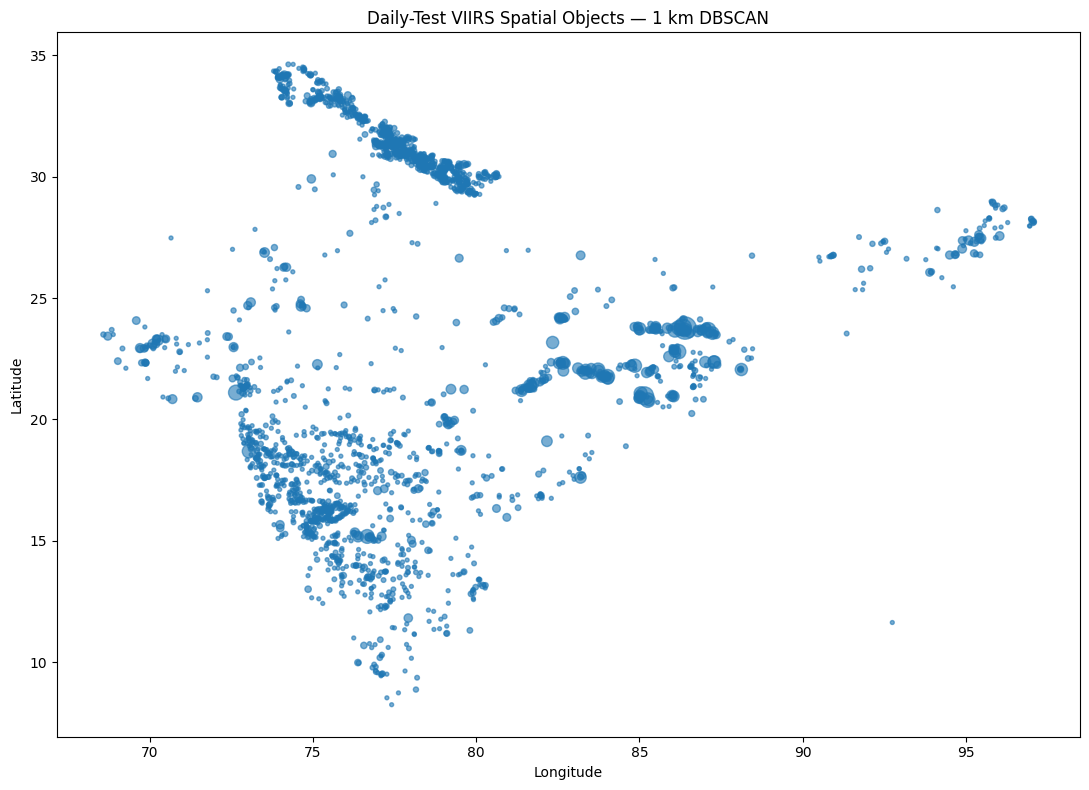

In [9]:
plt.figure(figsize=(11, 8))

plt.scatter(
    spatial_objects["centroid_lon"],
    spatial_objects["centroid_lat"],
    s=np.sqrt(
        spatial_objects["detection_count"]
    ) * 8,
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    "Daily-Test VIIRS Spatial Objects — 1 km DBSCAN"
)

plt.tight_layout()
plt.show()

In [10]:
def haversine_km(lat1, lon1, lat2, lon2):

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return (
        2 * EARTH_RADIUS_KM
        * np.arcsin(np.sqrt(a))
    )


test_centroids = spatial_objects[
    [
        "spatial_object_id",
        "centroid_lat",
        "centroid_lon"
    ]
]

test_check = test.merge(
    test_centroids,
    on="spatial_object_id",
    suffixes=("", "_centroid")
)

test_check["distance_from_centroid_km"] = haversine_km(
    test_check["latitude"],
    test_check["longitude"],
    test_check["centroid_lat"],
    test_check["centroid_lon"]
)

object_extent = (
    test_check
    .groupby("spatial_object_id")
    ["distance_from_centroid_km"]
    .max()
)

print(object_extent.describe())

count    2493.000000
mean        0.188591
std         0.371592
min         0.000000
25%         0.000000
50%         0.000000
75%         0.243082
max         7.107467
Name: distance_from_centroid_km, dtype: float64


In [11]:
display(
    object_extent
    .sort_values(ascending=False)
    .head(20)
)

spatial_object_id
12      7.107467
94      3.949977
26      3.375101
67      3.082464
49      3.072929
174     2.912939
61      2.479613
92      2.238205
72      2.174268
2111    2.060835
81      1.952420
111     1.952324
735     1.931069
758     1.910069
51      1.867223
31      1.860632
96      1.846180
617     1.799068
1       1.773056
689     1.771780
Name: distance_from_centroid_km, dtype: float64

In [12]:
parameter_results = []

for radius_km in [0.5, 1.0, 2.0]:

    model = DBSCAN(
        eps=radius_km / EARTH_RADIUS_KM,
        min_samples=1,
        metric="haversine",
        algorithm="ball_tree"
    )

    labels = model.fit_predict(
        coordinates_rad
    )

    sizes = (
        pd.Series(labels)
        .value_counts()
    )

    parameter_results.append({
        "radius_km": radius_km,
        "objects": len(sizes),
        "singletons": (sizes == 1).sum(),
        "singleton_pct":
            (sizes == 1).mean() * 100,
        "median_size":
            sizes.median(),
        "max_size":
            sizes.max()
    })

parameter_results = pd.DataFrame(
    parameter_results
)

display(parameter_results)

,radius_km,objects,singletons,singleton_pct,median_size,max_size
0,0.5,3012,1889,62.715803,1.0,720
1,1.0,2493,1388,55.675892,1.0,1043
2,2.0,2135,1120,52.459016,1.0,1367


In [13]:
parameter_results.to_csv(
    "daily_spatial_dbscan_parameter_test.csv",
    index=False
)

spatial_objects.to_csv(
    "viirs_test_spatial_objects.csv",
    index=False
)

print("Saved DBSCAN experiment results.")

Saved DBSCAN experiment results.
